# 🛡️ Insurance Fraud Detection Using Random Forest
**Darshan University — Machine Learning Unit-3**

This notebook trains a Random Forest Classifier on an insurance claims dataset to detect fraudulent claims.

---
## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

warnings.filterwarnings("ignore")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Section 2: Load Dataset

In [ ]:
print("Loading dataset...")
df = pd.read_csv("insurance_fraud_data.csv")

print("\n" + "="*40)
print("  INSURANCE FRAUD DETECTION")
print("  RANDOM FOREST CLASSIFIER")
print("="*40 + "\n")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("Column Names:")
for col in df.columns:
    print(f"  - {col}")

In [ ]:
print("First 5 Rows:")
df.head()

In [ ]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values Per Column:")
print(df.isnull().sum())

---
## Section 3: Data Preprocessing

In [ ]:
print("--- Data Preprocessing ---")

# Step 3a: Drop rows where the target column is missing
# (Only 8 rows have missing target – safe to drop them)
df = df.dropna(subset=["fraud reported"])
print(f"Rows after dropping missing target values: {len(df)}")

# Step 3b: Process claim_date – extract year, month, day
# claim_date is in format MM/DD/YYYY
df["claim_date"] = pd.to_datetime(df["claim_date"], format="%m/%d/%Y", errors="coerce")
df["claim_year"]  = df["claim_date"].dt.year
df["claim_month"] = df["claim_date"].dt.month
df["claim_day"]   = df["claim_date"].dt.day

# Remove the original claim_date column
df = df.drop(columns=["claim_date"])

# Step 3c: Remove claim_number – it is just an ID, not a predictive feature
df = df.drop(columns=["claim_number"])

# Step 3d: Convert injury_claim from object (string numbers) to float
df["injury_claim"] = pd.to_numeric(df["injury_claim"], errors="coerce")

# Step 3e: Replace '*' values (unknown/noise) in some columns with NaN
# so that the imputer can handle them properly
df.replace("*", np.nan, inplace=True)

print("Preprocessing steps completed: claim_date split, claim_number removed, '*' replaced with NaN.")

---
## Section 4: Separate Features and Target

In [ ]:
# X = all input features (everything except the target)
X = df.drop(columns=["fraud reported"])

# y = target column (Y = Fraud, N = Not Fraud)
y = df["fraud reported"]

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector y shape  : {y.shape}")
print(f"\nTarget class distribution:")
print(y.value_counts())

---
## Section 5: Identify Numerical and Categorical Columns

In [ ]:
# Numerical columns – will be imputed with median
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns – will be one-hot encoded
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical columns  ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

---
## Section 6: Train-Test Split

In [ ]:
# stratify=y ensures that both train and test sets have the same
# proportion of Fraud (Y) and Not Fraud (N) as the original dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples  : {len(X_train)}")
print(f"Testing Samples   : {len(X_test)}")

---
## Section 7: Create Preprocessing Pipeline

In [ ]:
# Numerical pipeline: fill missing values with the median of the column
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline:
#   Step 1 – fill missing values with the most frequent category
#   Step 2 – convert categories to one-hot encoded columns
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer applies the right pipeline to the right columns
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessing pipelines created.")

---
## Section 8: Create Random Forest Model Pipeline

Random Forest (as taught in Unit-3 PPT):
- **n_estimators**: number of decision trees (100 trees)
- **max_features="sqrt"**: at each node, consider √(total_features) features for the best split — adds randomness and reduces overfitting
- **Bootstrap sampling** is used by default (`bootstrap=True`)
- Each tree gives a prediction → majority vote → final class

In [ ]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        class_weight="balanced",  # accounts for imbalanced Fraud vs Not-Fraud classes
        random_state=42,
        n_jobs=-1        # use all CPU cores for faster training
    ))
])

print("Model pipeline created.")
print(model)

---
## Section 9: Train the Model

In [ ]:
print("Training Random Forest model...")

# fit() applies preprocessing ONLY on training data,
# then trains the Random Forest on the transformed data.
model.fit(X_train, y_train)

print("✅ Model training complete.")

---
## Section 10: Prediction

In [ ]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict class probabilities (useful for fraud probability %)
y_probability = model.predict_proba(X_test)

print(f"Predictions sample (first 10): {y_pred[:10].tolist()}")
print(f"Actual labels      (first 10): {y_test.iloc[:10].tolist()}")

---
## Section 11: Model Evaluation

In [ ]:
# pos_label="Y" means Fraud is the positive class
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Y")
recall    = recall_score(y_test, y_pred, pos_label="Y")
f1        = f1_score(y_test, y_pred, pos_label="Y")

print("="*40)
print("  MODEL PERFORMANCE")
print("="*40)
print(f"  Accuracy  : {accuracy  * 100:.2f}%")
print(f"  Precision : {precision * 100:.2f}%")
print(f"  Recall    : {recall    * 100:.2f}%")
print(f"  F1 Score  : {f1        * 100:.2f}%")
print("="*40)

---
## Section 12: Confusion Matrix

In [ ]:
# Get the classes in the correct order from the model
classes = model.classes_   # typically ['N', 'Y']

cm = confusion_matrix(y_test, y_pred, labels=classes)

print("Confusion Matrix:")
print(cm)

# Visualise with seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["N (Not Fraud)", "Y (Fraud)"],
    yticklabels=["N (Not Fraud)", "Y (Fraud)"]
)
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

---
## Section 13: Classification Report

In [15]:
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print("  N = Not Fraud   |   Y = Fraud\n")
print(classification_report(y_test, y_pred, target_names=["N (Not Fraud)", "Y (Fraud)"]))

CLASSIFICATION REPORT
  N = Not Fraud   |   Y = Fraud

               precision    recall  f1-score   support

N (Not Fraud)       0.77      1.00      0.87      1809
    Y (Fraud)       0.85      0.09      0.16       590

     accuracy                           0.77      2399
    macro avg       0.81      0.54      0.51      2399
 weighted avg       0.79      0.77      0.69      2399



---
## Section 14: Random Forest Tree Information

In [16]:
rf_clf = model.named_steps["classifier"]

print("="*50)
print("RANDOM FOREST INFORMATION")
print("="*50)
print(f"  Number of Trees (n_estimators) : {rf_clf.n_estimators}")
print(f"  Max Features per Split         : {rf_clf.max_features}")
print(f"  Bootstrap Sampling             : {rf_clf.bootstrap}")
print(f"  Class Weight                   : {rf_clf.class_weight}")
print("="*50)

RANDOM FOREST INFORMATION
  Number of Trees (n_estimators) : 100
  Max Features per Split         : sqrt
  Bootstrap Sampling             : True
  Class Weight                   : balanced


---
## Section 15: Feature Importance

In [17]:
# Get feature names after OneHotEncoding from the preprocessor
ohe_feature_names = (
    model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(categorical_cols)
)

# All feature names = numerical columns + one-hot encoded columns
all_feature_names = numerical_cols + list(ohe_feature_names)

# Get feature importances from the Random Forest
importances = rf_clf.feature_importances_

# Build a DataFrame for easy sorting
importance_df = pd.DataFrame({
    "Feature":    all_feature_names,
    "Importance": importances
})
importance_df = importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)

print("="*40)
print("  TOP 10 MOST IMPORTANT FEATURES")
print("="*40)
top10 = importance_df.head(10)
for rank, row in top10.iterrows():
    print(f"  {rank + 1:2d}. {row['Feature']:<35s} {row['Importance']:.6f}")
print("="*40)

top10

  TOP 10 MOST IMPORTANT FEATURES
   1. annual_income                       0.147383
   2. injury_claim                        0.055981
   3. total_claim                         0.054251
   4. vehicle_price                       0.053929
   5. zip_code                            0.053240
   6. days open                           0.051975
   7. safety_rating                       0.047894
   8. liab_prct                           0.047172
   9. annual premium                      0.043232
  10. age_of_driver                       0.042377


,Feature,Importance
0,annual_income,0.147383
1,injury_claim,0.055981
2,total_claim,0.054251
3,vehicle_price,0.053929
4,zip_code,0.053240
5,days open,0.051975
6,safety_rating,0.047894
7,liab_prct,0.047172
8,annual premium,0.043232
9,age_of_driver,0.042377


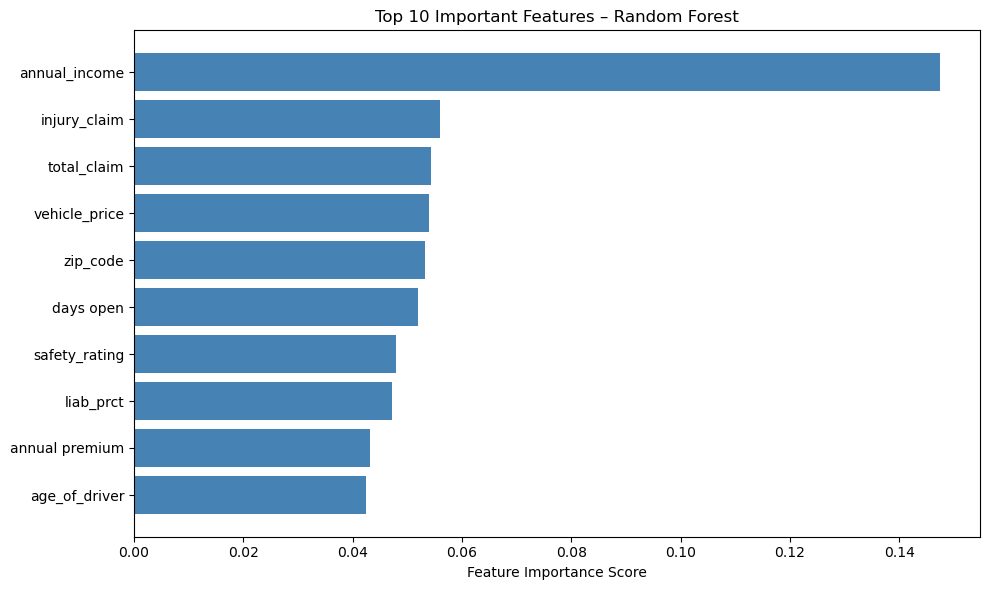

Feature importance chart saved as feature_importance.png


In [18]:
# Bar chart for top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance Score")
plt.title("Top 10 Important Features – Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Feature importance chart saved as feature_importance.png")

---
## Section 16: Save Model

In [19]:
model_filename = "insurance_fraud_random_forest.pkl"
joblib.dump(model, model_filename)

print("="*40)
print("  MODEL SAVED")
print("="*40)
print(f"  File: {model_filename}")
print("  The saved file contains BOTH:")
print("    - Preprocessing pipeline (ColumnTransformer)")
print("    - Random Forest Classifier")
print("  You can load and predict without re-preprocessing.")
print("="*40)

  MODEL SAVED
  File: insurance_fraud_random_forest.pkl
  The saved file contains BOTH:
    - Preprocessing pipeline (ColumnTransformer)
    - Random Forest Classifier
  You can load and predict without re-preprocessing.


---
## Section 17: Load Model & Verify

In [20]:
print("Loading saved model to verify...")
loaded_model = joblib.load(model_filename)

# Verify by predicting on a small sample of the test set
sample_pred = loaded_model.predict(X_test.iloc[:5])
print(f"Loaded model predictions (first 5 test rows): {sample_pred.tolist()}")
print(f"Actual labels                               : {y_test.iloc[:5].tolist()}")
print("✅ Model loaded and verified successfully.")

Loading saved model to verify...
Loaded model predictions (first 5 test rows): ['N', 'N', 'N', 'N', 'N']
Actual labels                               : ['Y', 'Y', 'Y', 'N', 'Y']
✅ Model loaded and verified successfully.


---
## Section 18: Single Claim Prediction Function

In [21]:
def predict_fraud(claim_data: dict) -> None:
    """
    Predict whether a single insurance claim is fraudulent.

    Parameters
    ----------
    claim_data : dict
        A dictionary with feature names and their values
        (same structure as the training data, without 'fraud reported').

    Returns
    -------
    Prints the prediction and fraud probability.
    """
    # Convert the dictionary to a one-row DataFrame
    claim_df = pd.DataFrame([claim_data])

    # Load the saved pipeline (preprocessing + Random Forest)
    pipeline = joblib.load("insurance_fraud_random_forest.pkl")

    # Make prediction
    prediction    = pipeline.predict(claim_df)[0]
    probabilities = pipeline.predict_proba(claim_df)[0]

    # Find the index of class "Y" (Fraud) in the model's class list
    classes = pipeline.classes_
    fraud_index = list(classes).index("Y")
    fraud_probability = probabilities[fraud_index] * 100

    print("\n--- Single Claim Prediction ---")
    print(f"  Prediction        : {'Fraud' if prediction == 'Y' else 'Not Fraud'}")
    print(f"  Fraud Probability : {fraud_probability:.2f}%")
    print("-------------------------------")

print("predict_fraud() function defined.")

predict_fraud() function defined.


---
## Section 19: Example – Single Claim Prediction

In [22]:
# Example claim – a new insurance claim record
example_claim = {
    "age_of_driver":      35,
    "gender":             "M",
    "marital_status":     "1",
    "safety_rating":      60,
    "annual_income":      50000.0,
    "high_education":     1,
    "address_change":     0,
    "property_status":    "Own",
    "zip_code":           12345,
    "claim_day_of_week":  "Monday",
    "accident_site":      "Highway",
    "past_num_of_claims": 1,
    "witness_present":    "1",
    "liab_prct":          30,
    "channel":            "Online",
    "police_report":      1,
    "age_of_vehicle":     "5",
    "vehicle_category":   "Medium",
    "vehicle_price":      25000.0,
    "vehicle_color":      "blue",
    "total_claim":        15000.0,
    "injury_claim":       5000.0,
    "policy deductible":  500,
    "annual premium":     1200.0,
    "days open":          7.5,
    "form defects":       2,
    "claim_year":         2024,
    "claim_month":        6,
    "claim_day":          15,
}

predict_fraud(example_claim)


--- Single Claim Prediction ---
  Prediction        : Not Fraud
  Fraud Probability : 20.00%
-------------------------------


---
## Final Summary

In [23]:
print("="*40)
print("  INSURANCE FRAUD DETECTION")
print("  RANDOM FOREST CLASSIFIER")
print("="*40 + "\n")
print(f"  Dataset Shape     : {df.shape[0]} rows, {df.shape[1]+1} columns")
print(f"  Training Samples  : {len(X_train)}")
print(f"  Testing Samples   : {len(X_test)}\n")
print(f"  Model             : Random Forest Classifier")
print(f"  Number of Trees   : {rf_clf.n_estimators}")
print(f"  Max Features      : {rf_clf.max_features}\n")
print("-"*40)
print("  MODEL PERFORMANCE")
print("-"*40)
print(f"  Accuracy  : {accuracy  * 100:.2f}%")
print(f"  Precision : {precision * 100:.2f}%")
print(f"  Recall    : {recall    * 100:.2f}%")
print(f"  F1 Score  : {f1        * 100:.2f}%")
print("-"*40)
print("  CONFUSION MATRIX")
print("-"*40)
print(f"\n{cm}\n")
print("-"*40)
print("  TOP 10 IMPORTANT FEATURES")
print("-"*40)
for rank, row in top10.iterrows():
    print(f"  {rank + 1:2d}. {row['Feature']:<35s} {row['Importance']:.6f}")
print("-"*40)
print("  MODEL SAVED")
print("-"*40)
print(f"  {model_filename}")
print("="*40)

  INSURANCE FRAUD DETECTION
  RANDOM FOREST CLASSIFIER

  Dataset Shape     : 11994 rows, 31 columns
  Training Samples  : 9595
  Testing Samples   : 2399

  Model             : Random Forest Classifier
  Number of Trees   : 100
  Max Features      : sqrt

----------------------------------------
  MODEL PERFORMANCE
----------------------------------------
  Accuracy  : 77.16%
  Precision : 85.00%
  Recall    : 8.64%
  F1 Score  : 15.69%
----------------------------------------
  CONFUSION MATRIX
----------------------------------------

[[1800    9]
 [ 539   51]]

----------------------------------------
  TOP 10 IMPORTANT FEATURES
----------------------------------------
   1. annual_income                       0.147383
   2. injury_claim                        0.055981
   3. total_claim                         0.054251
   4. vehicle_price                       0.053929
   5. zip_code                            0.053240
   6. days open                           0.051975
   7. safety